## **ESPECIFICACIONES**

**No olvide duplicar esta notebook para poder editar: File->Save a copy in Drive**

Completar las actividades requeridas dentro de este mismo notebook de Google Colab. Una vez finalizadas las actividades, enviar a la plataforma sea el PDF generado o el link compardio, i.e.,:

1. Un archivo PDF generado en Google Colab desde el menú "Archivo" -> "Imprimir".

2. El enlace público de Google Colab. Para ello, vaya al botón de compartir y cambie la configuración de compartición a "Cualquier persona con el enlace".

 ## **1. DATASET**

In [ ]:
# @title
import os
from matplotlib import pyplot as plt   #Libreria que permite hacer plot
from PIL import Image #Procesamiento Digital de IMágenes PIL: Python Image Library
import numpy as np
if not os.path.exists('lfwcrop_grey'):

    !wget http://conradsanderson.id.au/lfwcrop/lfwcrop_grey.zip

    !unzip 'lfwcrop_grey.zip'

filenames = []
images = []

for filename in os.listdir('lfwcrop_grey/faces'):
    filenames.append(filename)
    image = np.array(Image.open(os.path.join('lfwcrop_grey/faces', filename)))
    images.append(image)

images = np.array(images)

print('Total Number of Faces: {}'.format(len(images)))
print(images.shape)
n = 64*64 #dimensión de mis datos (original) n = 4096 features
X = images.reshape(13233, n) # m = 13233 ejemplos de entrenamiento
print(X.shape)

Total Number of Faces: 13233
(13233, 64, 64)
(13233, 4096)



 ## **2. VISUALIZACIÓN DE LAS IMAGENES (DATASET)**

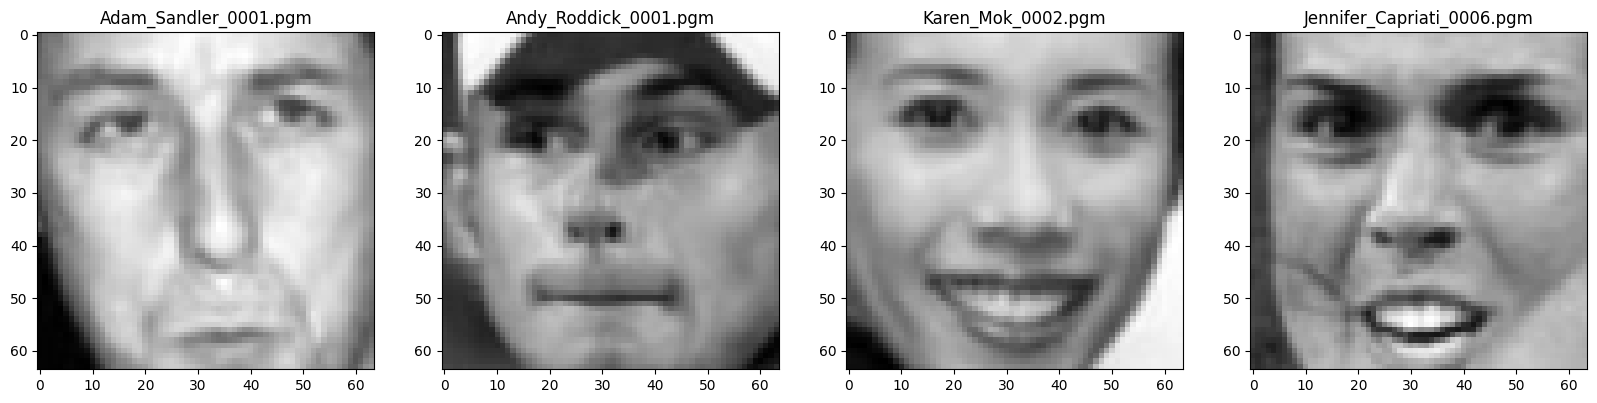

In [ ]:
# @title
plt.figure(figsize=(20, 10))  #size de la imagen

num_images = 4 #Numero de imagenes
for i in range(num_images):

    plt.subplot(1, num_images, i+1)
    index = np.random.choice(range(len(images)))
    image = images[index]
    filename=filenames[index]
    plt.imshow(image, 'gray')  #que imprima en grises

    plt.title(filename)  #Imprima el nombre

 ## **3. COMPRESIÓN DE IMAGENES CON SVD**



Paso 1: Compresión de la Imagen (Reducción de la Dimensionalidad)


In [ ]:
# @title
# SVD para PCA
print("Calculando SVD...")
X_mean = np.mean(X, axis=0)  # Calcular la media de cada columna
X_centered = X - X_mean  # Centrar los datos
# Aplicar SVD
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)  # SVD
# Determinar el número de componentes necesarios para retener al menos el 70% de la varianza
# se cambia VR a 0.95 de 0.80 y las expresiones faciales todavía se pierden
# se deja en 0.97
VR = 0.97  # Proporción mínima de varianza explicada deseada
explained_variance = S**2  # Varianza explicada proporcional a los valores singulares al cuadrado (calculamos los eigenvalues)
total_variance = np.sum(explained_variance)  # Varianza total

# Sumar varianza explicada acumulada y determinar el número de componentes
cumulative_variance_ratio = np.cumsum(explained_variance) / total_variance
k = np.argmax(cumulative_variance_ratio >= VR) + 1  # Número de componentes necesarios
print(f"Número de componentes seleccionados para retener al menos el {VR*100}% de la varianza: {k}")

# Reducción de dimensionalidad usando los primeros k componentes
V_reduce = Vt[:k, :]  # Tomar las primeras k filas de Vt
Z = np.dot(X_centered, V_reduce.T)  # Proyectar los datos en el espacio reducido

# Mostrar los resultados
print("Dimensión original:", X.shape)
print("Dimensión reducida:", Z.shape)

# Verificar proporción de varianza explicada por k componentes
variance_retained = np.sum(explained_variance[:k]) / total_variance
print(f"Proporción de varianza explicada por {k} componentes: {variance_retained:.2f}")


Calculando SVD...
Número de componentes seleccionados para retener al menos el 97.0% de la varianza: 276
Dimensión original: (13233, 4096)
Dimensión reducida: (13233, 276)
Proporción de varianza explicada por 276 componentes: 0.97


Paso 2: Reconstrucción de la Imagen

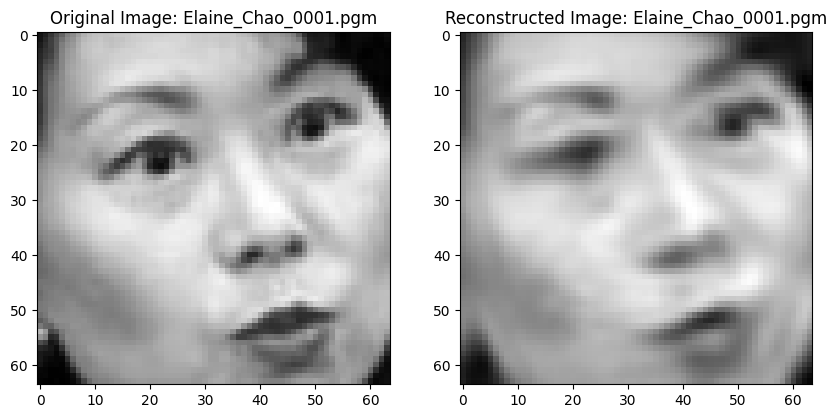

In [ ]:
# @title
import random
# Reconstrucción de los datos
X_approx = np.dot(Z, V_reduce) + X_mean  # Transformación inversa al espacio original

# Seleccionar una imagen aleatoria para graficar
# se remueve seed para que no salga la misma imagen
#random.seed(877)
index = random.randint(0,13233)    #Escoge un aleatorio entre 0 a 13233 imaenes
reconstructed_image = X_approx[index] # Reconstruir la imagen
reconstructed_image = reconstructed_image.reshape(64, 64)
original_image = images[index]  # Imagen original

# Mostrar la imagen original y la reconstruida
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Original Image: ' + filenames[index]) # Se agrega el nombre
plt.imshow(original_image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('Reconstructed Image: ' + filenames[index]) # Se agrega el nombre
plt.imshow(reconstructed_image, cmap='gray')

plt.show()

 ## **4. COMPRESIÓN DE IMAGENES CON PCA**

Paso 1: Compresión de la Imagen (Reducción de la Dimensionalidad)


In [ ]:
# @title
#Importar librerias
from sklearn import preprocessing
from sklearn.decomposition import PCA

explained_variance = 0.99 #varianza retenida =  varianza explicada = "información" retenida
pca = PCA(explained_variance) #solo construyo el objeto pca, se usa la función, argumento dice que quiere que calcule para la información retenida el 0.99
pca.fit(X) #Implementa [U, S, V^T] = svd(Sigma); Vreduce = V(1:k,:) (ver diapositvas). Selecciona automáticamente k de modo que se retenga 99% de la varianza.
#De cada 13233 de 64*64 = 4096 que son features, con el pca ahora disminuye a 577 features, disminuyendo la calidad de imagen.
z = pca.transform(X) # Implementa z = X_centered.Vreduce (ver diapositivas).
Vreduce = pca.components_.T #Vreduce nxk, reduciendo componentes principales
#puede demorar unos minutos
K = pca.n_components_

#Imprimir información
print("Los datos originales tienen dimensión", X.shape)
print("Los datos comprimidos tienen dimensión", z.shape)
print("El número de componentes principales K es", K, " que retienen el ", explained_variance*100, "% de la varianza")
print("El tam. de Ureduce (matriz de eigenvectors) es", Vreduce.shape)
print("PCA consigue reducir el tamaño en disco al ", K/n*100, "% de su tam. original")

Los datos originales tienen dimensión (13233, 4096)
Los datos comprimidos tienen dimensión (13233, 577)
El número de componentes principales K es 577  que retienen el  99.0 % de la varianza
El tam. de Ureduce (matriz de eigenvectors) es (4096, 577)
PCA consigue reducir el tamaño en disco al  14.0869140625 % de su tam. original


Paso 2: Reconstrucción de la Imagen

Label Thabo_Mbeki_0005.pgm


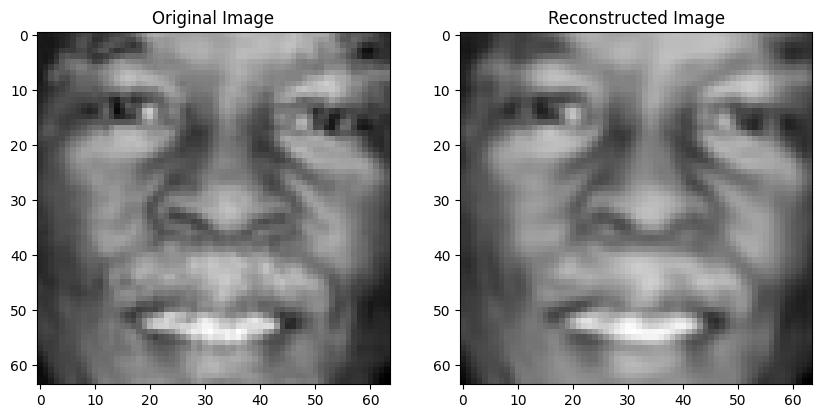

In [ ]:
# @title
import random     #Se escoge 1 de todas las imagenes
# se quita el seed para que no salga siempre la misma imagen
#random.seed(a=877)

#Implementa x_approx = z.Vreduce+mean
X_approx = pca.inverse_transform(z)
# índice de la imagen a graficar
index = random.randint(0,13233)    #Escoge un aleatorio entre 0 a 13233 imagenes
reconstructed_image = X_approx[index]
reconstructed_image = reconstructed_image.reshape(64, 64)
print('Label {}'.format(filenames[index]))
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)    #Imprime 2 imagenes la original posicion 1
plt.title('Original Image')
plt.imshow(images[index], 'gray')

plt.subplot(1, 2, 2) #Imprime 2 imagenes la reconstruida posicion 1
plt.title('Reconstructed Image')
plt.imshow(reconstructed_image, 'gray')

## **5. ACTIVIDAD 1: COMPRESIÓN DE IMAGENES**

**5.1 Varianza retenida vs Numero de componentes (k)**

Grafique la varianza retenida en función del número de componentes principales retenidos k. Para esto, modifique la variable `explained_variance` con los siguientes valores: 0.99, 0.75, 0.3

Para cada valor, verifique el número de componentes principales retenidos k.

Varianza retenida = 0.99 -> k = 577 componentes
Varianza retenida = 0.75 -> k = 22 componentes
Varianza retenida = 0.3 -> k = 2 componentes


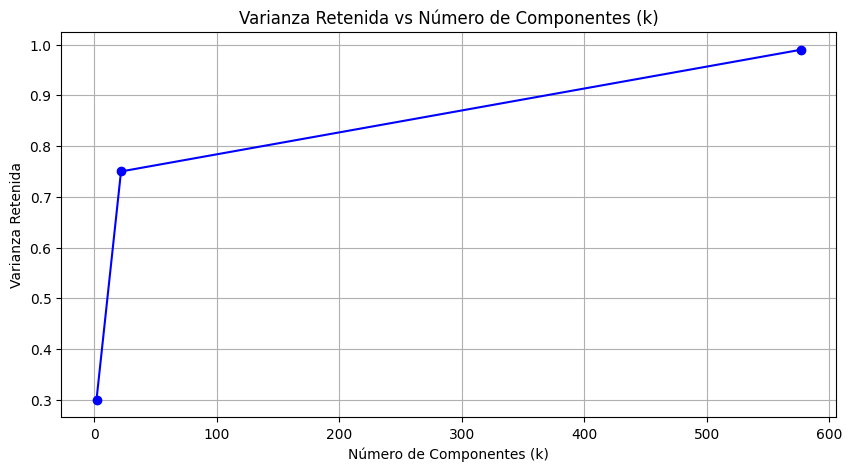

In [ ]:
#Insertar código

from sklearn import preprocessing
from sklearn.decomposition import PCA
varianza = [0.99, 0.75,0.3]
num_compo_k=[]

for varianzaActual in varianza:

  explained_variance = varianzaActual #varianza retenida =  varianza explicada = "información" retenida porcentaje
  #inserte el codigo aqui
  pca = PCA(explained_variance)  # se crea el objeto PCA
      # pca.fit calcula los componentes principales
      # necesarios para retener ese porcentaje de varianza.
  pca.fit(X)                     # ajusta el PCA sobre el dataset de rostros (X, 13233 x 4096)
  k = pca.n_components_
  num_compo_k.append(k)          # se guardan los k pcomponentes ara poder graficarlo despues
  print(f"Varianza retenida = {explained_variance} -> k = {k} componentes")



#aqui codigo para dibujar
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.title('Varianza Retenida vs Número de Componentes (k)')
plt.plot(num_compo_k, varianza, marker='o', linestyle='-', color='b')
plt.xlabel('Número de Componentes (k)')
plt.ylabel('Varianza Retenida')
plt.grid(True)
plt.show()


**5.2 Calidad vs. Componente**

Tomar una imagen propia (selfie) en escala de grises y aplicar PCA para obtener una representación comprimida. Reconstruir la imagen utilizando componentes que preserven el 70% y el 99% de la varianza, y comparar visualmente las reconstrucciones con la imagen original.



**Compresión**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


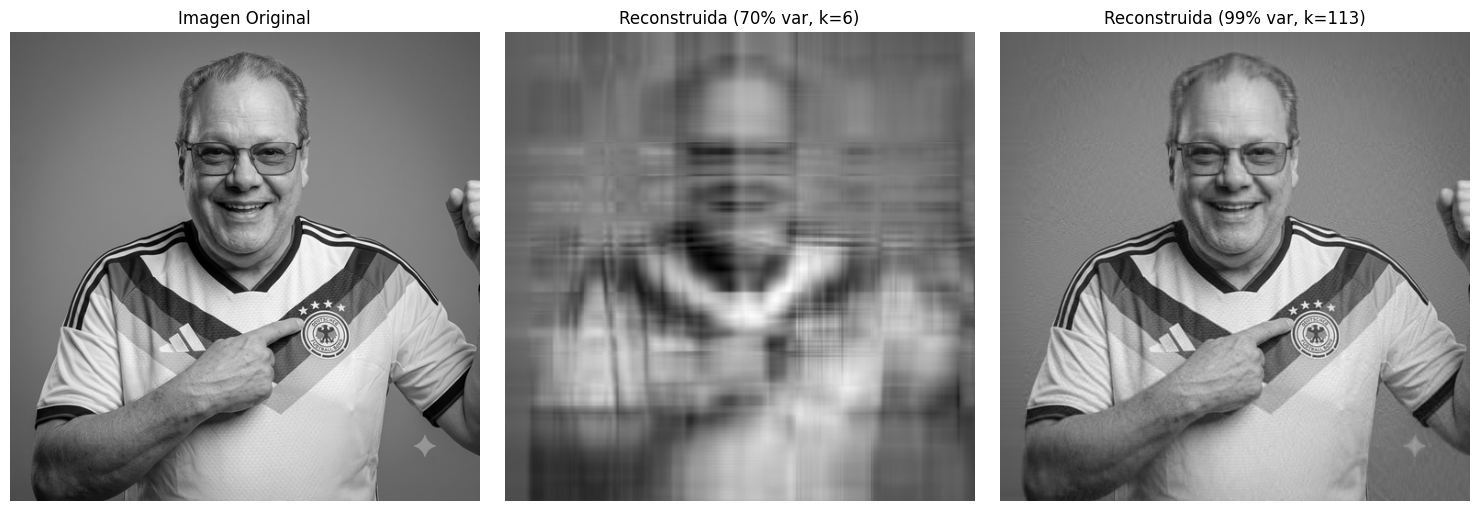

--- Caso 70% ---
Dimensión original: (512, 512)
Dimensión comprimida: (512, 6)
Número de componentes principales K: 6
Varianza retenida: 0.7141336498746614
--- Caso 99% ---
Dimensión original: (512, 512)
Dimensión comprimida: (512, 113)
Número de componentes principales K: 113
Varianza retenida: 0.9900419406371218


In [ ]:
#Librerias
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from google.colab import drive
# 1 Cargar imagen
drive.mount('/content/drive')
img = Image.open("/content/drive/MyDrive/Colab Notebooks/IMG_9576.jpeg")  # formatos aceptados jpeg, png, jpg
img_gray = img.convert("L")  # convertimos a escala de grises
img_resized = img_gray.resize((512, 512), Image.LANCZOS)  # redimensionar la imagen
img_array = np.array(img_resized, dtype=float)        # obtener la matriz numérica de la imagen


# 2. Aplicar PCA para compresión
# img_array tiene dimensión (512, 512)
#
# En este ejercicio:
# - cada fila se considera una muestra      -> 512 muestras
# - cada columna se considera una feature  -> 512 features
#
# Aplicar PCA conservando:
# a) 70% de la varianza
# b) 99% de la varianza

# insertar su código de PCA aquí
pca_70 = PCA(n_components=0.70)          # PCA que retiene el 70% de la varianza
Z_70 = pca_70.fit_transform(img_array)   # ajusta y proyecta la imagen al espacio reducido

pca_99 = PCA(n_components=0.99)          # PCA que retiene el 99% de la varianza
Z_99 = pca_99.fit_transform(img_array)   # ajusta y proyecta la imagen al espacio reducido


# 3. Reconstrucción
# Reconstruir la imagen utilizando inverse_transform()

# insertar su código para reconstruir la imagen
img_approx_70 = pca_70.inverse_transform(Z_70)  # reconstrucción con 70% de varianza
img_approx_99 = pca_99.inverse_transform(Z_99)  # reconstrucción con 99% de varianza

# 4. Visualización
# Mostrar:
# - imagen original
# - reconstrucción con 70% de varianza
# - reconstrucción con 99% de varianza

# insertar su código de visualización
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(img_array, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f'Reconstruida (70% var, k={pca_70.n_components_})')
plt.imshow(img_approx_70, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(f'Reconstruida (99% var, k={pca_99.n_components_})')
plt.imshow(img_approx_99, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


# 5. Mostrar información
# Para cada caso (70% y 99%), mostrar:
#
# - dimensión de la imagen original
# - dimensión de la representación comprimida
# - número de componentes principales utilizados
# - porcentaje de varianza retenida
for etiqueta, pca_obj, Z in [('70%', pca_70, Z_70), ('99%', pca_99, Z_99)]:
    print(f"--- Caso {etiqueta} ---")
    print("Dimensión original:", img_array.shape)
    print("Dimensión comprimida:", Z.shape)
    print("Número de componentes principales K:", pca_obj.n_components_)
    print("Varianza retenida:", np.sum(pca_obj.explained_variance_ratio_))

Se puede concluir que desde un 97% las expresiones faciales del dataset no se pierden, con valores inferiores se reduce la información desde el punto de vista de los datos pero las imagenes dejan de ser expresivas. En el selfie también se pierde mucha información y la reconstrucción solo sirve en valores altos de varianza por lo que no se pueden sacar tantos componentes principales. La varianza acumulada no es necesariamente un criterio para decidir.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **ACTIVIDAD 2: Uso de DataSet Genérico**

Escoger un dataSet genérico de interés del repositorio proporcionado y aplicar PCA.

[UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/)  

Varianza explicada por cada componente (PC1, PC2): [0.12759508 0.03409105]
Varianza total explicada por PC1+PC2: 0.1616861295650978

Top variables por |PC1|:
                    PC1       PC2
PT08.S2(NMHC)  0.311167 -0.033883
C6H6(GT)       0.307372 -0.021130
PT08.S4(NO2)   0.305474  0.096881
CO(GT)         0.303263  0.017950
PT08.S1(CO)    0.301308  0.064257
PT08.S5(O3)    0.295170  0.088189
NOx(GT)        0.294903  0.053211
PT08.S3(NOx)  -0.287789 -0.011980
NO2(GT)        0.282580 -0.075061
NMHC(GT)       0.276547 -0.026104

Top variables por |PC2|:
                     PC1       PC2
RH             -0.045210  0.581187
T               0.139586 -0.419910
AH              0.128502  0.338842
Date_4/16/2004  0.034490  0.158378
Date_4/30/2004  0.040352  0.155672
Time_7:00:00    0.001252  0.132192
Time_15:00:00   0.000982 -0.125224
Time_16:00:00   0.002605 -0.124969
Time_13:00:00   0.009810 -0.122570
Time_14:00:00   0.002973 -0.119459


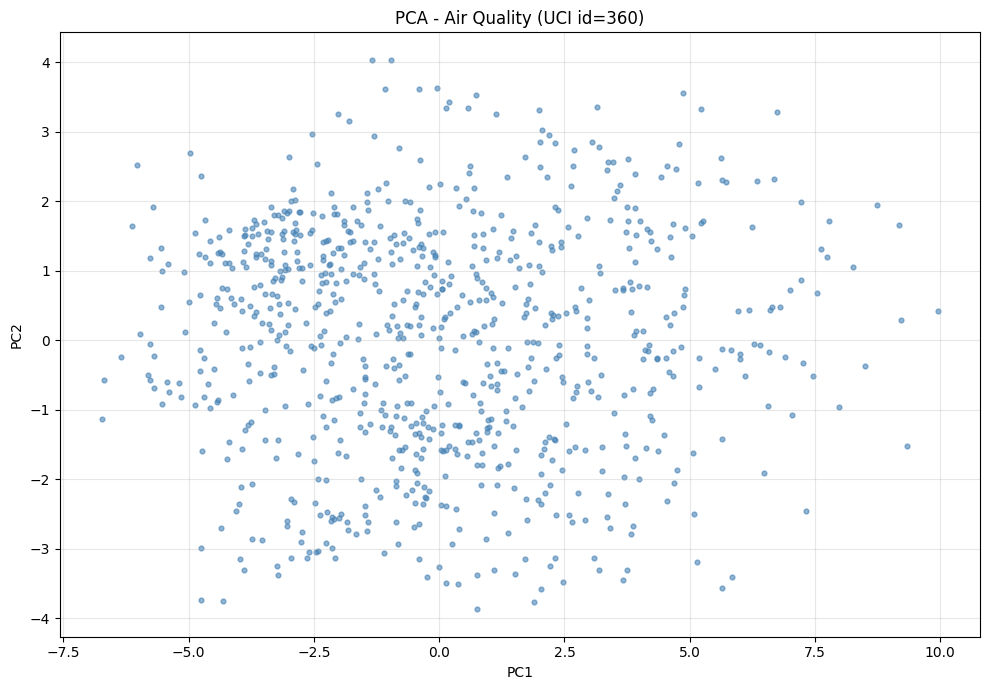

In [ ]:
# Instalar
!pip install -q ucimlrepo
# Link: https://archive.ics.uci.edu/dataset/360/air+quality
# PCA puro sobre features de Air Quality (UCI id=360)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from ucimlrepo import fetch_ucirepo

# 1) Cargar dataset (Cambiar el número de id para el dataSet Escogido)
air_quality = fetch_ucirepo(id=360)
X = air_quality.data.features   # solo features

# Ingresar su código aqui (no olvidar los loadings para poder discutir los datos)

# 2) Preprocesar X
# El dataset Air Quality trae columnas "Date" y "Time" (texto) y usa el valor
# -200 como código de dato faltante en las columnas numéricas de sensores.
X_proc = pd.get_dummies(X, drop_first=True)          # one-hot a las columnas categóricas (Date, Time)
X_proc = X_proc.replace(-200, np.nan)                # -200 es el código de "missing" en este dataset
X_proc = X_proc.replace([np.inf, -np.inf], np.nan).dropna()  # se quitan inf y NaN

# 3) Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_proc)   # PCA necesita variables en la misma escala (media 0, var 1)

# 4) PCA (2 componentes; se podría usar n_components=0.95 para variar retenida)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por cada componente (PC1, PC2):", pca.explained_variance_ratio_)
print("Varianza total explicada por PC1+PC2:", pca.explained_variance_ratio_.sum())

# 5) Loadings (qué variables definen cada componente)
loadings = pd.DataFrame(pca.components_.T,
                         index=X_proc.columns,
                         columns=["PC1", "PC2"])
print("\nTop variables por |PC1|:")
print(loadings.reindex(loadings.PC1.abs().sort_values(ascending=False).index).head(10))
print("\nTop variables por |PC2|:")
print(loadings.reindex(loadings.PC2.abs().sort_values(ascending=False).index).head(10))

# 6) Gráfico (PCA puro, sin variable objetivo)
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=12, alpha=0.6, color="steelblue")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Air Quality (UCI id=360)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **RESPONDER**

¿El PCA fue útil en este dataset?

Respuesta 1

En realidad no tanto pues los valores de la varianza explicada de PC1 y PC1+PC2 son de %12.76 y %16.17. Nótese que los valores propios no son proporcionalmente altos.
Los Loadings sin embargo indican ara PC1 que las contribuciones son casi iguales y son variables de los sensores que van juntas y son proxys entre sí, salvo el PT08.S3(NOx) que va en la dirección contraria. Para el PC2 se lo llevan las variables RH y AH pero T va en la dirección contraria, por lo que es un componente meterorológico.


.
¿Se lograron patrones visibles (agrupaciones, separaciones)?, si es así, escribir su interpretación sobre los resultados

Respuesta 2
En el plot no hay separación clara o direcciones definidas que muestren clusters o diferencias en la varianza relativa. Las direcciones de PC1 y PC2 halan a su manera
Las variables de los sensores y las variables meterorológicas son fenómenos separados e independientes prácticamente, por lo que no interactuan mutuamente sino cada grupo por su lado.
